## 1. Kurulum

In [9]:
!pip install -q transformers datasets accelerate peft bitsandbytes scikit-learn matplotlib seaborn hf_transfer
!pip install -U -q peft transformers accelerate bitsandbytes
!pip uninstall -y torchao
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [10]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f'Colab: {IN_COLAB}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True


In [11]:
import os, json, pickle, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding,
                          EarlyStoppingCallback, BitsAndBytesConfig)
from peft import (LoraConfig, get_peft_model, TaskType,
                  prepare_model_for_kbit_training, PeftModel)
import transformers
transformers.logging.set_verbosity_error()

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('UYARI: Qwen 7B CPU\'da çalışmaz, GPU runtime seç.')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 85.1 GB


## 2. Yollar

In [ ]:
if IN_COLAB:
    BASE = Path('/content/drive/MyDrive/bitirme/sentiment')
    REVIEWS_CSV = Path('/content/drive/MyDrive/bitirme/data/processed/reviews_merged.csv')
    CKPT_BASE = Path('/content/checkpoints_qwen')
else:
    BASE = Path('/Users/melihyelman/Desktop/bitirme/sentiment')
    REVIEWS_CSV = Path('/Users/melihyelman/Desktop/bitirme/data/processed/reviews_merged.csv')
    CKPT_BASE = BASE / 'checkpoints_qwen'

DATA_DIR   = BASE / 'data'
MODEL_DIR  = BASE / 'models'
OUTPUT_DIR = BASE / 'outputs'
for d in (MODEL_DIR, OUTPUT_DIR, CKPT_BASE):
    d.mkdir(parents=True, exist_ok=True)

print(f'BASE        : {BASE}')
print(f'DATA_DIR    : {DATA_DIR}')
print(f'MODEL_DIR   : {MODEL_DIR}    (adapter ağırlıkları → Drive)')
print(f'CKPT_BASE   : {CKPT_BASE}    (eğitim checkpoint → local SSD)')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')
print(f'REVIEWS_CSV : {REVIEWS_CSV}')

BASE        : /content/drive/MyDrive/bitirme/sentiment
DATA_DIR    : /content/drive/MyDrive/bitirme/sentiment/data
MODEL_DIR   : /content/drive/MyDrive/bitirme/sentiment/models    (adapter ağırlıkları → Drive)
CKPT_BASE   : /content/checkpoints_qwen    (eğitim checkpoint → local SSD)
OUTPUT_DIR  : /content/drive/MyDrive/bitirme/sentiment/outputs
REVIEWS_CSV : /content/drive/MyDrive/bitirme/data/processed/reviews_merged.csv


## 3. Yardımcı Fonksiyonlar — QLoRA ayarları

In [ ]:
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

QWEN_BASE = '/content/drive/MyDrive/bitirme/qwen_cache/Qwen2.5-7B-Instruct'

GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
IS_A100_BIG = GPU_MEM_GB >= 60   
print(f'GPU bellek: {GPU_MEM_GB:.1f} GB | A100 80GB modu: {IS_A100_BIG}')
print(f'Model yolu: {QWEN_BASE}')

import os
if os.path.isdir(QWEN_BASE):
    files = sorted(os.listdir(QWEN_BASE))
    print(f'Drive cache içeriği ({len(files)} dosya):')
    for f in files:
        size = os.path.getsize(os.path.join(QWEN_BASE, f)) / 1e9
        print(f'  {f}: {size:.2f} GB' if size > 0.001 else f'  {f}')
else:
    print(f'Model klasörü bulunamadı: {QWEN_BASE}')
    print('   Drive\'a yüklediğinden emin ol, sync tamamlandı mı kontrol et')

def load_pkl(path):
    path = Path(path)
    if str(path).endswith('.csv'):
        df = pd.read_csv(path)
    else:
        with open(path, 'rb') as f:
            df = pickle.load(f)
    df = df.dropna(subset=['sentence', 'emotion']).reset_index(drop=True)
    df['sentence'] = df['sentence'].astype(str)
    return df

def make_splits(df, test_size=0.10, val_size=0.10, seed=SEED):
    le = LabelEncoder()
    df = df.copy()
    df['label'] = le.fit_transform(df['emotion'])
    train_val, test = train_test_split(df, test_size=test_size,
                                        stratify=df['label'], random_state=seed)
    train, val = train_test_split(train_val, test_size=val_size / (1 - test_size),
                                   stratify=train_val['label'], random_state=seed)
    print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')
    print(f'Sınıflar ({len(le.classes_)}): {list(le.classes_)}')
    return train, val, test, le

def to_dataset(df, tokenizer, max_length=128):
    ds = Dataset.from_pandas(df[['sentence', 'label']].reset_index(drop=True))
    return ds.map(lambda x: tokenizer(x['sentence'], truncation=True,
                                       max_length=max_length, padding=False),
                  batched=True)

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits') if isinstance(outputs, dict) else outputs.logits
        if self.class_weights is not None:
            w = self.class_weights.to(logits.device).to(logits.dtype)
            loss_fn = nn.CrossEntropyLoss(weight=w)
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def load_qwen_for_classification(num_labels):
    tokenizer = AutoTokenizer.from_pretrained(QWEN_BASE, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'right'

    if IS_A100_BIG:
        print('Mode: FULL BF16 (A100 80GB için optimize)')
        model = AutoModelForSequenceClassification.from_pretrained(
            QWEN_BASE,
            num_labels=num_labels,
            torch_dtype=torch.bfloat16,
            device_map='auto',
            trust_remote_code=True,
        )
    else:
        print('Mode: QLoRA 4-bit')
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForSequenceClassification.from_pretrained(
            QWEN_BASE,
            num_labels=num_labels,
            quantization_config=bnb_config,
            device_map='auto',
            trust_remote_code=True,
        )
        model = prepare_model_for_kbit_training(model)

    model.config.pad_token_id = tokenizer.pad_token_id

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias='none',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        modules_to_save=['score'],
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model, tokenizer

def train_qwen(train_ds, val_ds, num_labels, ckpt_dir,
               epochs=3, batch_size=None, grad_accum=None, lr=1e-4):
    import inspect
    model, tokenizer = load_qwen_for_classification(num_labels)

    if batch_size is None:
        batch_size = 32 if IS_A100_BIG else 4
    if grad_accum is None:
        grad_accum = 1 if IS_A100_BIG else 4
    print(f'Batch size: {batch_size}, Grad accum: {grad_accum}, Etkin: {batch_size * grad_accum}')

    train_labels = np.array(train_ds['label'])
    class_weights_np = compute_class_weight('balanced',
                                             classes=np.arange(num_labels),
                                             y=train_labels)
    class_weights = torch.tensor(class_weights_np, dtype=torch.float)
    print(f'Class weights: {dict(enumerate(class_weights_np.round(3)))}')

    args = TrainingArguments(
        output_dir=str(ckpt_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr,
        warmup_ratio=0.05,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        bf16=True,
        gradient_checkpointing=not IS_A100_BIG,
        optim='adamw_torch' if IS_A100_BIG else 'paged_adamw_8bit',
        logging_steps=50,
        save_total_limit=2,
        report_to='none',
        seed=SEED,
        dataloader_num_workers=4 if IS_A100_BIG else 2,
        remove_unused_columns=True,
    )

    trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights,
    )
    sig = inspect.signature(Trainer.__init__).parameters
    if 'processing_class' in sig:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer
    trainer = WeightedTrainer(**trainer_kwargs)
    trainer.train()
    return trainer, model, tokenizer

def evaluate_on_test(trainer, test_ds, le, title='', save_path=None):
    pred = trainer.predict(test_ds)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_true = pred.label_ids
    print(f'\n=== Test Sonuçları ({title}) ===')
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
    plt.title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

def save_qwen_adapter(model, tokenizer, le, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)
    with open(out_dir / 'label_classes.json', 'w', encoding='utf-8') as f:
        json.dump(list(le.classes_), f, ensure_ascii=False, indent=2)
    with open(out_dir / 'base_model.txt', 'w') as f:
        f.write(QWEN_BASE)
    print(f'Kaydedildi: {out_dir}')

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    print(f'GPU bellek (free/total): '
          f'{torch.cuda.mem_get_info()[0] / 1e9:.1f} / {torch.cuda.mem_get_info()[1] / 1e9:.1f} GB')

GPU bellek: 85.1 GB | A100 80GB modu: True
Model yolu: /content/drive/MyDrive/bitirme/qwen_cache/Qwen2.5-7B-Instruct
Drive cache içeriği (11 dosya):
  config.json
  generation_config.json
  merges.txt: 0.00 GB
  model-00001-of-00004.safetensors: 3.95 GB
  model-00002-of-00004.safetensors: 3.86 GB
  model-00003-of-00004.safetensors: 3.86 GB
  model-00004-of-00004.safetensors: 3.56 GB
  model.safetensors.index.json
  tokenizer.json: 0.01 GB
  tokenizer_config.json
  vocab.json: 0.00 GB


## 4. Türkçe Model

In [ ]:
TR_OUT = MODEL_DIR / 'qwen_tr_final'

tr_df = load_pkl(DATA_DIR / 'türkçe_final.csv')
print(f'TR örnek: {len(tr_df):,}')
print(tr_df['emotion'].value_counts())

TR örnek: 12,000
emotion
anger        2000
disgust      2000
fear         2000
happiness    2000
sadness      2000
neutral      2000
Name: count, dtype: int64


In [15]:
tr_train, tr_val, tr_test, tr_le = make_splits(tr_df)
_tok = AutoTokenizer.from_pretrained(QWEN_BASE, trust_remote_code=True)
if _tok.pad_token is None:
    _tok.pad_token = _tok.eos_token
tr_train_ds = to_dataset(tr_train, _tok)
tr_val_ds   = to_dataset(tr_val,   _tok)
tr_test_ds  = to_dataset(tr_test,  _tok)
del _tok

Train: 9,600 | Val: 1,200 | Test: 1,200
Sınıflar (6): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [16]:
tr_trainer, tr_model, tr_tokenizer = train_qwen(
    tr_train_ds, tr_val_ds,
    num_labels=len(tr_le.classes_),
    ckpt_dir=CKPT_BASE / 'qwen_tr',
    epochs=3, lr=1e-4,
)

Mode: FULL BF16 (A100 80GB için optimize)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 10,114,048 || all params: 7,080,754,688 || trainable%: 0.1428
Batch size: 32, Grad accum: 1, Etkin: 32
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0)}
{'loss': '5.839', 'grad_norm': '58.79', 'learning_rate': '9.953e-05', 'epoch': '0.1667'}
{'loss': '0.9115', 'grad_norm': '34.64', 'learning_rate': '9.368e-05', 'epoch': '0.3333'}
{'loss': '0.4498', 'grad_norm': '17.38', 'learning_rate': '8.784e-05', 'epoch': '0.5'}
{'loss': '0.3513', 'grad_norm': '20.25', 'learning_rate': '8.199e-05', 'epoch': '0.6667'}
{'loss': '0.2932', 'grad_norm': '40.42', 'learning_rate': '7.614e-05', 'epoch': '0.8333'}
{'loss': '0.29', 'grad_norm': '11.85', 'learning_rate': '7.029e-05', 'epoch': '1'}
{'eval_loss': '0.2731', 'eval_accuracy': '0.9133', 'eval_f1_macro': '0.9128', 'eval_f1_weighted': '0.9128', 'eval_runtime': '5.207', 'eval_samples_per_second': '230.5', 'eval_steps_per_second': '3.649', 'epoch': '1


=== Test Sonuçları (Qwen 2.5 7B TR) ===
              precision    recall  f1-score   support

       anger     0.9069    0.9250    0.9158       200
     disgust     0.9333    0.9800    0.9561       200
        fear     0.9888    0.8850    0.9340       200
   happiness     0.9590    0.9350    0.9468       200
     neutral     1.0000    1.0000    1.0000       200
     sadness     0.8726    0.9250    0.8981       200

    accuracy                         0.9417      1200
   macro avg     0.9434    0.9417    0.9418      1200
weighted avg     0.9434    0.9417    0.9418      1200



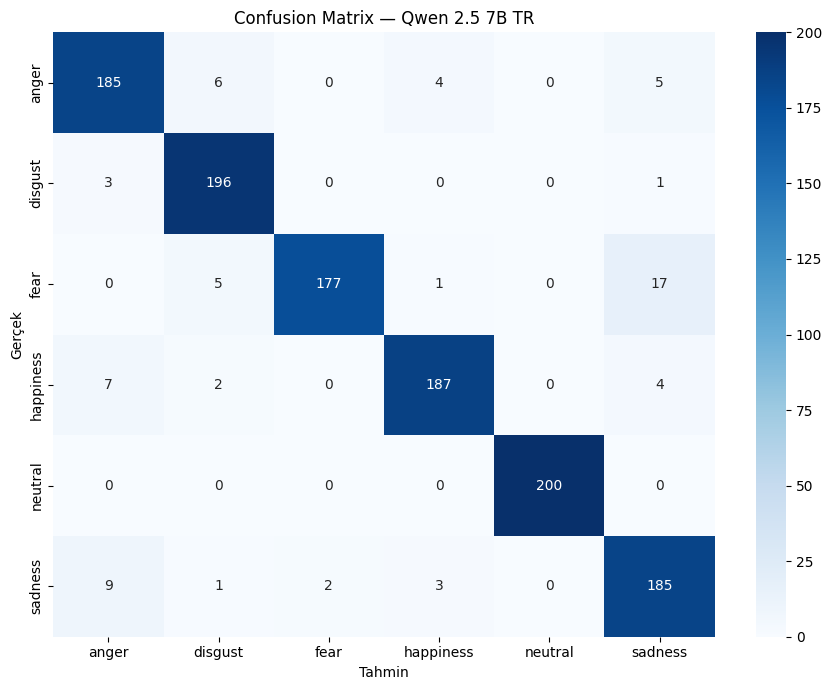

{'accuracy': 0.9416666666666667, 'f1_macro': 0.9418116299855283, 'f1_weighted': 0.9418116299855281}


In [17]:
tr_metrics = evaluate_on_test(tr_trainer, tr_test_ds, tr_le,
                               title='Qwen 2.5 7B TR',
                               save_path=OUTPUT_DIR / 'qwen_tr_confusion.png')
print(tr_metrics)

In [18]:
save_qwen_adapter(tr_model, tr_tokenizer, tr_le, TR_OUT)

del tr_trainer, tr_model, tr_tokenizer
free_memory()

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/models/qwen_tr_final
GPU bellek (free/total): 55.8 / 85.1 GB


## 5. İngilizce Model

In [ ]:
EN_OUT = MODEL_DIR / 'qwen_en_final'

en_df = load_pkl(DATA_DIR / 'ingilizce_final.csv')
print(f'EN örnek: {len(en_df):,}')
print(en_df['emotion'].value_counts())

EN örnek: 9,000
emotion
anger        1500
disgust      1500
fear         1500
happiness    1500
neutral      1500
sadness      1500
Name: count, dtype: int64


In [20]:
en_train, en_val, en_test, en_le = make_splits(en_df)
_tok = AutoTokenizer.from_pretrained(QWEN_BASE, trust_remote_code=True)
if _tok.pad_token is None:
    _tok.pad_token = _tok.eos_token
en_train_ds = to_dataset(en_train, _tok)
en_val_ds   = to_dataset(en_val,   _tok)
en_test_ds  = to_dataset(en_test,  _tok)
del _tok

Train: 7,199 | Val: 901 | Test: 900
Sınıflar (6): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


Map:   0%|          | 0/7199 [00:00<?, ? examples/s]

Map:   0%|          | 0/901 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [21]:
en_trainer, en_model, en_tokenizer = train_qwen(
    en_train_ds, en_val_ds,
    num_labels=len(en_le.classes_),
    ckpt_dir=CKPT_BASE / 'qwen_en',
    epochs=3, lr=1e-4,
)

Mode: FULL BF16 (A100 80GB için optimize)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 10,114,048 || all params: 7,080,754,688 || trainable%: 0.1428
Batch size: 32, Grad accum: 1, Etkin: 32
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.001), 4: np.float64(1.0), 5: np.float64(1.0)}
{'loss': '6.02', 'grad_norm': '80.9', 'learning_rate': '9.766e-05', 'epoch': '0.2222'}
{'loss': '2.193', 'grad_norm': '40.3', 'learning_rate': '8.986e-05', 'epoch': '0.4444'}
{'loss': '1.14', 'grad_norm': '40.39', 'learning_rate': '8.206e-05', 'epoch': '0.6667'}
{'loss': '0.9945', 'grad_norm': '27.76', 'learning_rate': '7.426e-05', 'epoch': '0.8889'}
{'eval_loss': '0.8086', 'eval_accuracy': '0.7137', 'eval_f1_macro': '0.709', 'eval_f1_weighted': '0.7091', 'eval_runtime': '2.734', 'eval_samples_per_second': '329.6', 'eval_steps_per_second': '5.487', 'epoch': '1'}
{'loss': '0.7789', 'grad_norm': '68.08', 'learning_rate': '6.646e-05', 'epoch': '1.111'}
{'loss': '0.7013', 'grad_norm': '39.68', 'learning_rate': '5.866e-05', 'epoch': '1.


=== Test Sonuçları (Qwen 2.5 7B EN) ===
              precision    recall  f1-score   support

       anger     0.6299    0.6467    0.6382       150
     disgust     0.8365    0.8867    0.8608       150
        fear     0.8981    0.9400    0.9186       150
   happiness     0.8690    0.8400    0.8542       150
     neutral     0.6212    0.5467    0.5816       150
     sadness     0.7059    0.7200    0.7129       150

    accuracy                         0.7633       900
   macro avg     0.7601    0.7633    0.7610       900
weighted avg     0.7601    0.7633    0.7610       900



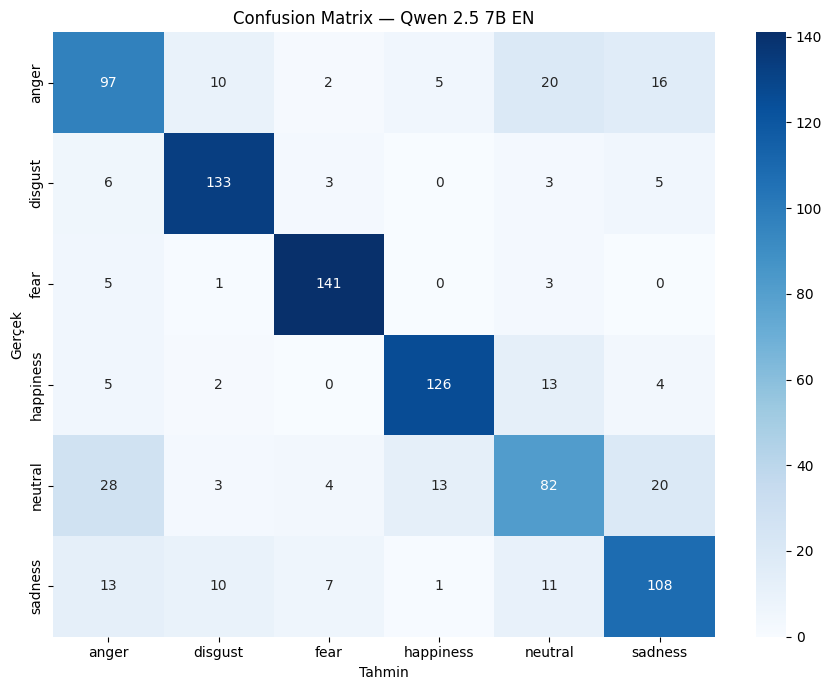

{'accuracy': 0.7633333333333333, 'f1_macro': 0.7610391588136017, 'f1_weighted': 0.7610391588136018}


In [22]:
en_metrics = evaluate_on_test(en_trainer, en_test_ds, en_le,
                               title='Qwen 2.5 7B EN',
                               save_path=OUTPUT_DIR / 'qwen_en_confusion.png')
print(en_metrics)

In [23]:
save_qwen_adapter(en_model, en_tokenizer, en_le, EN_OUT)

del en_trainer, en_model, en_tokenizer
free_memory()

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/models/qwen_en_final
GPU bellek (free/total): 55.8 / 85.1 GB


## 6. Model Performans Özeti

In [24]:
summary = pd.DataFrame({
    'Model': ['Qwen 2.5 7B TR (final-6)', 'Qwen 2.5 7B EN (final-6)'],
    'Accuracy':     [tr_metrics['accuracy'],     en_metrics['accuracy']],
    'F1 (macro)':   [tr_metrics['f1_macro'],     en_metrics['f1_macro']],
    'F1 (weighted)':[tr_metrics['f1_weighted'],  en_metrics['f1_weighted']],
})
summary.to_csv(OUTPUT_DIR / 'qwen_performans_ozeti_final.csv', index=False, encoding='utf-8-sig')
print(summary.to_string(index=False))

                   Model  Accuracy  F1 (macro)  F1 (weighted)
Qwen 2.5 7B TR (final-6)  0.941667    0.941812       0.941812
Qwen 2.5 7B EN (final-6)  0.763333    0.761039       0.761039


## 7. Inference — Film Yorumlarına Duygu Etiketi


In [25]:
reviews_df = pd.read_csv(REVIEWS_CSV)
print(f'Yorum: {len(reviews_df):,}')
print(reviews_df['language'].value_counts())
reviews_df['sentiment'] = None

Yorum: 382,977
language
en    191562
tr    191415
Name: count, dtype: int64


In [ ]:
def load_adapter_for_inference(adapter_dir):
    adapter_dir = Path(adapter_dir)
    with open(adapter_dir / 'label_classes.json') as f:
        classes = json.load(f)
    le = LabelEncoder()
    le.classes_ = np.array(classes)

    if IS_A100_BIG:
        base = AutoModelForSequenceClassification.from_pretrained(
            QWEN_BASE, num_labels=len(classes),
            torch_dtype=torch.bfloat16,
            device_map='auto', trust_remote_code=True,
        )
    else:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        base = AutoModelForSequenceClassification.from_pretrained(
            QWEN_BASE, num_labels=len(classes),
            quantization_config=bnb_config,
            device_map='auto', trust_remote_code=True,
        )

    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base.config.pad_token_id = tokenizer.pad_token_id

    model = PeftModel.from_pretrained(base, str(adapter_dir))
    model.eval()
    return model, tokenizer, le

@torch.no_grad()
def predict_batch(texts, model, tokenizer, le, batch_size=None, max_length=256):
    if batch_size is None:
        batch_size = 64 if IS_A100_BIG else 16
    print(f'Inference batch size: {batch_size}')
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            logits = model(**enc).logits
        preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
        if (i // batch_size) % 20 == 0:
            print(f'  {i + len(batch):,} / {len(texts):,}')
    return [le.classes_[p] for p in preds]

In [27]:
tr_mask = reviews_df['language'] == 'tr'
print(f'TR yorum: {tr_mask.sum():,}')

model_tr, tok_tr, le_tr = load_adapter_for_inference(TR_OUT)
tr_sent = predict_batch(reviews_df.loc[tr_mask, 'review_text'].astype(str).tolist(),
                         model_tr, tok_tr, le_tr, max_length=256)
reviews_df.loc[tr_mask, 'sentiment'] = tr_sent

del model_tr, tok_tr
free_memory()

TR yorum: 191,415


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Inference batch size: 64
  64 / 191,415
  1,344 / 191,415
  2,624 / 191,415
  3,904 / 191,415
  5,184 / 191,415
  6,464 / 191,415
  7,744 / 191,415
  9,024 / 191,415
  10,304 / 191,415
  11,584 / 191,415
  12,864 / 191,415
  14,144 / 191,415
  15,424 / 191,415
  16,704 / 191,415
  17,984 / 191,415
  19,264 / 191,415
  20,544 / 191,415
  21,824 / 191,415
  23,104 / 191,415
  24,384 / 191,415
  25,664 / 191,415
  26,944 / 191,415
  28,224 / 191,415
  29,504 / 191,415
  30,784 / 191,415
  32,064 / 191,415
  33,344 / 191,415
  34,624 / 191,415
  35,904 / 191,415
  37,184 / 191,415
  38,464 / 191,415
  39,744 / 191,415
  41,024 / 191,415
  42,304 / 191,415
  43,584 / 191,415
  44,864 / 191,415
  46,144 / 191,415
  47,424 / 191,415
  48,704 / 191,415
  49,984 / 191,415
  51,264 / 191,415
  52,544 / 191,415
  53,824 / 191,415
  55,104 / 191,415
  56,384 / 191,415
  57,664 / 191,415
  58,944 / 191,415
  60,224 / 191,415
  61,504 / 191,415
  62,784 / 191,415
  64,064 / 191,415
  65,344 / 191,41

In [28]:
en_mask = reviews_df['language'] == 'en'
print(f'EN yorum: {en_mask.sum():,}')

model_en, tok_en, le_en = load_adapter_for_inference(EN_OUT)
en_sent = predict_batch(reviews_df.loc[en_mask, 'review_text'].astype(str).tolist(),
                         model_en, tok_en, le_en, max_length=256)
reviews_df.loc[en_mask, 'sentiment'] = en_sent

del model_en, tok_en
free_memory()

EN yorum: 191,562


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Inference batch size: 64
  64 / 191,562
  1,344 / 191,562
  2,624 / 191,562
  3,904 / 191,562
  5,184 / 191,562
  6,464 / 191,562
  7,744 / 191,562
  9,024 / 191,562
  10,304 / 191,562
  11,584 / 191,562
  12,864 / 191,562
  14,144 / 191,562
  15,424 / 191,562
  16,704 / 191,562
  17,984 / 191,562
  19,264 / 191,562
  20,544 / 191,562
  21,824 / 191,562
  23,104 / 191,562
  24,384 / 191,562
  25,664 / 191,562
  26,944 / 191,562
  28,224 / 191,562
  29,504 / 191,562
  30,784 / 191,562
  32,064 / 191,562
  33,344 / 191,562
  34,624 / 191,562
  35,904 / 191,562
  37,184 / 191,562
  38,464 / 191,562
  39,744 / 191,562
  41,024 / 191,562
  42,304 / 191,562
  43,584 / 191,562
  44,864 / 191,562
  46,144 / 191,562
  47,424 / 191,562
  48,704 / 191,562
  49,984 / 191,562
  51,264 / 191,562
  52,544 / 191,562
  53,824 / 191,562
  55,104 / 191,562
  56,384 / 191,562
  57,664 / 191,562
  58,944 / 191,562
  60,224 / 191,562
  61,504 / 191,562
  62,784 / 191,562
  64,064 / 191,562
  65,344 / 191,56

In [29]:
out_csv = OUTPUT_DIR / 'reviews_with_sentiment_qwen_final.csv'
reviews_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'Kaydedildi: {out_csv}')
print()
print('Duygu × dil dağılımı:')
print(pd.crosstab(reviews_df['sentiment'], reviews_df['language'], margins=True))

Kaydedildi: /content/drive/MyDrive/bitirme/sentiment/outputs/reviews_with_sentiment_qwen_final.csv

Duygu × dil dağılımı:
language       en      tr     All
sentiment                        
anger       35028   85373  120401
disgust      5864    7562   13426
fear        12936   21043   33979
happiness   30693   52946   83639
neutral     83181    5733   88914
sadness     23860   18758   42618
All        191562  191415  382977
